
# Sintético: Clústeres de pacientes, EDA y KNN
Este cuaderno genera datos **ficticios** de 100 pacientes, realiza **EDA**, entrena un modelo **KNN** y muestra un **ejemplo de consumo** (una línea CSV tipo laboratorio) y un **diagrama** de la metodología.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
import pickle

np.random.seed(42)


In [2]:

# 1) Generación de datos sintéticos con 3 clústeres bien definidos
N = 100
sizes = [35, 35, 30]  # A (saludable), B (riesgo metabólico), C (alto riesgo cardio-renal)

centers = {
    "A": {"age": 35, "bmi": 22, "systolic_bp": 115, "diastolic_bp": 75, "resting_hr": 65,
          "hdl": 60, "ldl": 100, "triglycerides": 90, "glucose_fasting": 90, "hba1c": 5.2,
          "alt": 20, "ast": 18, "crp": 1.0, "creatinine": 0.9, "egfr": 110,
          "wbc": 6.5, "rbc": 4.8, "platelets": 250, "prs": 0.2, "exercise_min_week": 180,
          "smoking_index": 0, "pc1": 0.0, "pc2": 0.0, "sex_at_birth": 0.5,
          "bp_medication": 0.05, "statin_use": 0.10},
    "B": {"age": 50, "bmi": 30, "systolic_bp": 135, "diastolic_bp": 85, "resting_hr": 75,
          "hdl": 45, "ldl": 140, "triglycerides": 180, "glucose_fasting": 105, "hba1c": 5.9,
          "alt": 35, "ast": 30, "crp": 3.0, "creatinine": 1.1, "egfr": 90,
          "wbc": 7.5, "rbc": 5.0, "platelets": 270, "prs": 0.6, "exercise_min_week": 60,
          "smoking_index": 1, "pc1": 0.5, "pc2": -0.3, "sex_at_birth": 0.5,
          "bp_medication": 0.35, "statin_use": 0.45},
    "C": {"age": 62, "bmi": 33, "systolic_bp": 150, "diastolic_bp": 95, "resting_hr": 85,
          "hdl": 40, "ldl": 170, "triglycerides": 250, "glucose_fasting": 130, "hba1c": 6.8,
          "alt": 45, "ast": 40, "crp": 6.0, "creatinine": 1.6, "egfr": 60,
          "wbc": 8.5, "rbc": 4.5, "platelets": 300, "prs": 0.8, "exercise_min_week": 20,
          "smoking_index": 2, "pc1": -0.4, "pc2": 0.6, "sex_at_birth": 0.5,
          "bp_medication": 0.70, "statin_use": 0.75}
}

noise_sd = {"age": 5, "bmi": 2, "systolic_bp": 7, "diastolic_bp": 5, "resting_hr": 5,
            "hdl": 5, "ldl": 10, "triglycerides": 25, "glucose_fasting": 8, "hba1c": 0.3,
            "alt": 5, "ast": 4, "crp": 0.6, "creatinine": 0.15, "egfr": 8,
            "wbc": 0.8, "rbc": 0.25, "platelets": 30, "prs": 0.1, "exercise_min_week": 40,
            "pc1": 0.15, "pc2": 0.15}

def bernoulli(n, p): return np.random.binomial(1, p, size=n)

rows = []
cluster_names = ["A", "B", "C"]

for cluster_name, size in zip(cluster_names, sizes):
    c = centers[cluster_name]
    age = np.random.normal(c["age"], noise_sd["age"], size)
    bmi = np.random.normal(c["bmi"], noise_sd["bmi"], size)
    systolic_bp = np.random.normal(c["systolic_bp"], noise_sd["systolic_bp"], size)
    diastolic_bp = np.random.normal(c["diastolic_bp"], noise_sd["diastolic_bp"], size)
    resting_hr = np.random.normal(c["resting_hr"], noise_sd["resting_hr"], size)

    hdl = np.random.normal(c["hdl"], noise_sd["hdl"], size)
    ldl = np.random.normal(c["ldl"], noise_sd["ldl"], size)
    triglycerides = np.random.normal(c["triglycerides"], noise_sd["triglycerides"], size)
    total_chol = ldl + hdl + 0.2 * triglycerides

    glucose_fasting = np.random.normal(c["glucose_fasting"], noise_sd["glucose_fasting"], size)
    hba1c = np.random.normal(c["hba1c"], noise_sd["hba1c"], size)

    alt = np.random.normal(c["alt"], noise_sd["alt"], size)
    ast = np.random.normal(c["ast"], noise_sd["ast"], size)
    crp = np.random.normal(c["crp"], noise_sd["crp"], size)

    creatinine = np.random.normal(c["creatinine"], noise_sd["creatinine"], size)
    egfr = np.clip(np.random.normal(c["egfr"], noise_sd["egfr"], size), 5, None)

    wbc = np.random.normal(c["wbc"], noise_sd["wbc"], size)
    rbc = np.random.normal(c["rbc"], noise_sd["rbc"], size)
    platelets = np.random.normal(c["platelets"], noise_sd["platelets"], size)

    prs = np.random.normal(c["prs"], noise_sd["prs"], size)
    exercise_min_week = np.clip(np.random.normal(c["exercise_min_week"], noise_sd["exercise_min_week"], size), 0, None)

    pc1 = np.random.normal(c["pc1"], noise_sd["pc1"], size)
    pc2 = np.random.normal(c["pc2"], noise_sd["pc2"], size)

    sex_at_birth = np.random.binomial(1, c["sex_at_birth"], size)
    smoking_index = np.round(np.clip(np.random.normal(c["smoking_index"], 0.4, size), 0, 2)).astype(int)
    bp_medication = bernoulli(size, c["bp_medication"])
    statin_use = bernoulli(size, c["statin_use"])

    for i in range(size):
        rows.append({
            "age": age[i], "bmi": bmi[i], "systolic_bp": systolic_bp[i], "diastolic_bp": diastolic_bp[i],
            "resting_hr": resting_hr[i], "hdl": hdl[i], "ldl": ldl[i], "triglycerides": triglycerides[i],
            "total_chol": total_chol[i], "glucose_fasting": glucose_fasting[i], "hba1c": hba1c[i],
            "alt": alt[i], "ast": ast[i], "crp": crp[i], "creatinine": creatinine[i], "egfr": egfr[i],
            "wbc": wbc[i], "rbc": rbc[i], "platelets": platelets[i], "prs": prs[i],
            "exercise_min_week": exercise_min_week[i], "pc1": pc1[i], "pc2": pc2[i],
            "sex_at_birth": sex_at_birth[i], "smoking_index": smoking_index[i],
            "bp_medication": bp_medication[i], "statin_use": statin_use[i], "cluster": cluster_name
        })

df = pd.DataFrame(rows)

# Clips
df["bmi"] = df["bmi"].clip(16, 45)
df["systolic_bp"] = df["systolic_bp"].clip(90, 200)
df["diastolic_bp"] = df["diastolic_bp"].clip(50, 130)
df["hdl"] = df["hdl"].clip(20, 100)
df["ldl"] = df["ldl"].clip(40, 220)
df["triglycerides"] = df["triglycerides"].clip(40, 600)
df["total_chol"] = df["ldl"] + df["hdl"] + 0.2 * df["triglycerides"]
df["glucose_fasting"] = df["glucose_fasting"].clip(65, 300)
df["hba1c"] = df["hba1c"].clip(4.5, 12)
df["alt"] = df["alt"].clip(5, 200)
df["ast"] = df["ast"].clip(5, 200)
df["crp"] = df["crp"].clip(0.1, 50)
df["creatinine"] = df["creatinine"].clip(0.3, 6)
df["egfr"] = df["egfr"].clip(5, 140)
df["wbc"] = df["wbc"].clip(3, 20)
df["rbc"] = df["rbc"].clip(3, 7)
df["platelets"] = df["platelets"].clip(100, 700)
df["prs"] = df["prs"].clip(0, 1)

df.head()


,age,bmi,systolic_bp,diastolic_bp,resting_hr,hdl,ldl,triglycerides,total_chol,glucose_fasting,...,platelets,prs,exercise_min_week,pc1,pc2,sex_at_birth,smoking_index,bp_medication,statin_use,cluster
0,37.483571,19.558313,117.529769,77.020254,66.137300,64.135916,105.708905,81.637469,186.172315,90.908139,...,234.699508,0.030754,184.257209,-0.078408,0.070890,0,0,0,0,A
1,34.308678,22.417727,125.766256,84.430930,71.535714,60.065009,111.355656,78.126367,187.045939,95.297045,...,241.903752,0.352955,169.800911,0.157351,0.038404,1,0,0,0,A
2,38.238443,18.080660,114.749218,75.872889,56.962584,67.267670,109.540018,73.666769,191.541042,102.688135,...,220.637089,0.184199,240.159720,-0.105652,0.147404,1,0,0,0,A
3,42.615149,19.343628,125.952506,76.287752,65.923169,58.676716,106.513913,134.136356,192.017900,80.097476,...,236.671202,0.157312,73.961208,-0.211269,0.249821,1,0,0,0,A
4,33.829233,22.393722,96.661784,74.627770,66.299414,73.600846,96.847308,100.124543,190.473062,107.064267,...,261.319015,0.098790,223.660274,-0.233494,0.152156,0,0,0,0,A


In [3]:

# 2) EDA: resumen por clúster y algunas ideas
summary = df.groupby("cluster").agg({
    "age": "mean", "bmi": "mean", "systolic_bp": "mean", "diastolic_bp": "mean",
    "hdl": "mean", "ldl": "mean", "triglycerides": "mean", "glucose_fasting": "mean",
    "hba1c": "mean", "crp": "mean", "egfr": "mean", "prs": "mean",
    "exercise_min_week": "mean", "smoking_index": "mean", "bp_medication": "mean", "statin_use": "mean"
}).round(2)
display(summary)

print("\nINSIGHTS EDA:")
print("- El clúster C muestra mayor edad, IMC, presión arterial, LDL, triglicéridos y HbA1c, con menor eGFR y mayor PCR; también mayor uso de fármacos.")
print("- El clúster A exhibe mayor actividad física y mejor perfil lipídico y glucémico.")
print("- El clúster B es intermedio: riesgo metabólico creciente y hábitos en posiciones intermedias.")


,age,bmi,systolic_bp,diastolic_bp,hdl,ldl,triglycerides,glucose_fasting,hba1c,crp,egfr,prs,exercise_min_week,smoking_index,bp_medication,statin_use
cluster,,,,,,,,,,,,,,,,
A,34.34,21.73,114.18,75.25,60.96,100.20,88.30,91.87,5.17,1.00,108.98,0.18,178.79,0.03,0.09,0.03
B,50.79,29.87,135.17,86.25,44.57,140.93,178.10,104.94,5.95,2.81,88.92,0.59,53.29,1.09,0.46,0.49
C,63.14,32.40,149.01,94.92,39.71,170.86,252.82,129.64,6.79,6.03,59.81,0.84,28.68,1.93,0.60,0.83



INSIGHTS EDA:
- El clúster C muestra mayor edad, IMC, presión arterial, LDL, triglicéridos y HbA1c, con menor eGFR y mayor PCR; también mayor uso de fármacos.
- El clúster A exhibe mayor actividad física y mejor perfil lipídico y glucémico.
- El clúster B es intermedio: riesgo metabólico creciente y hábitos en posiciones intermedias.


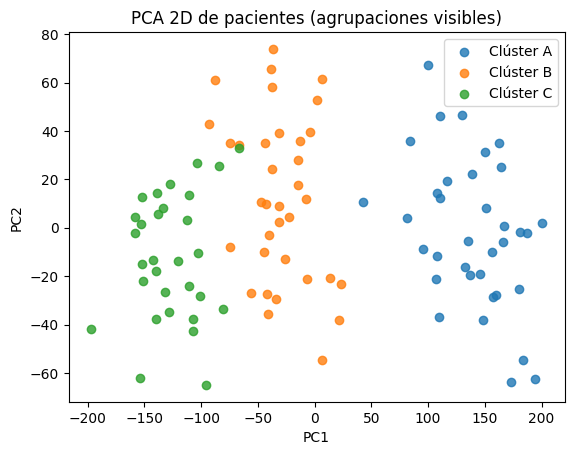

In [4]:

from sklearn.decomposition import PCA

features = [c for c in df.columns if c not in ["cluster"]]
X_all = df[features].values
y_all = df["cluster"].values

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all)

plt.figure()
for label in np.unique(y_all):
    idx = (y_all == label)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"Clúster {label}", alpha=0.8)
plt.title("PCA 2D de pacientes (agrupaciones visibles)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()


/tmp/ipython-input-4203228419.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"Clúster {c}" for c in cluster_names])


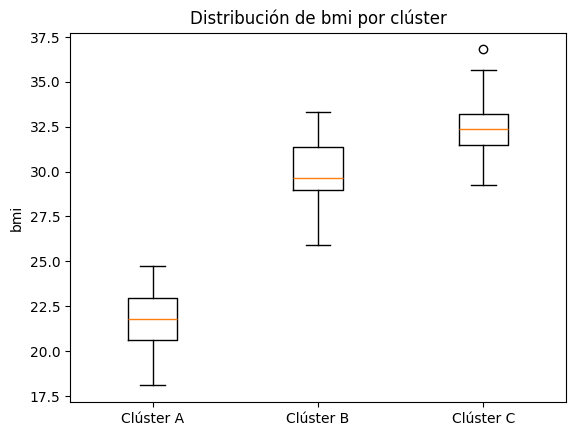

/tmp/ipython-input-4203228419.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"Clúster {c}" for c in cluster_names])


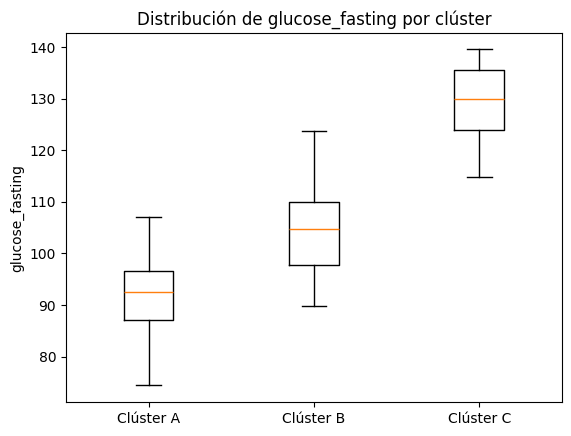

/tmp/ipython-input-4203228419.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"Clúster {c}" for c in cluster_names])


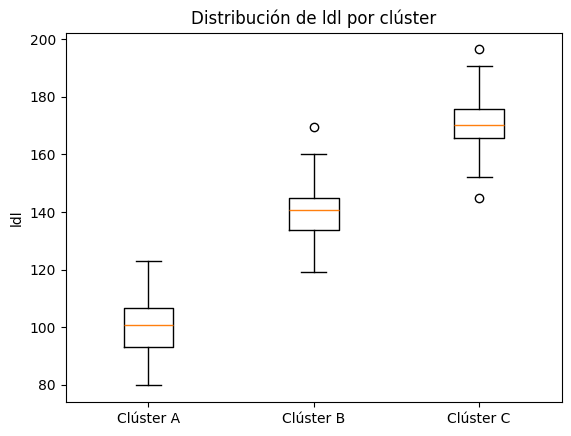

/tmp/ipython-input-4203228419.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"Clúster {c}" for c in cluster_names])


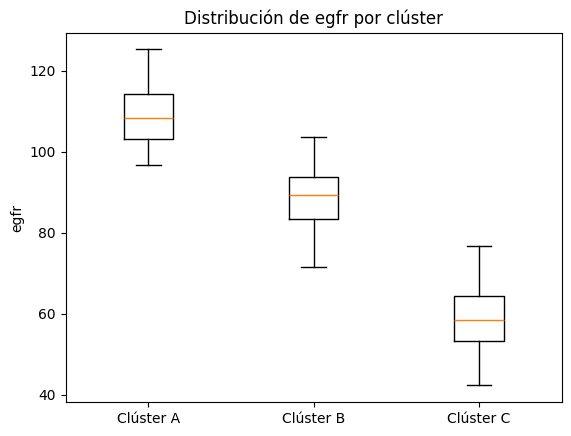

/tmp/ipython-input-4203228419.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[f"Clúster {c}" for c in cluster_names])


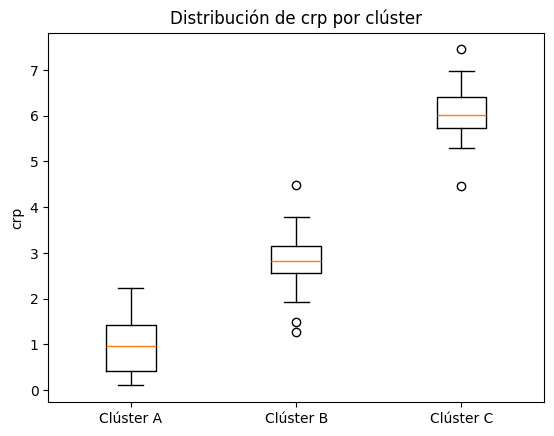

In [5]:

selected_features = ["bmi", "glucose_fasting", "ldl", "egfr", "crp"]
cluster_names = ["A", "B", "C"]
for feat in selected_features:
    data = [df[df["cluster"] == c][feat].values for c in cluster_names]
    plt.figure()
    plt.boxplot(data, labels=[f"Clúster {c}" for c in cluster_names])
    plt.title(f"Distribución de {feat} por clúster")
    plt.ylabel(feat)
    plt.show()


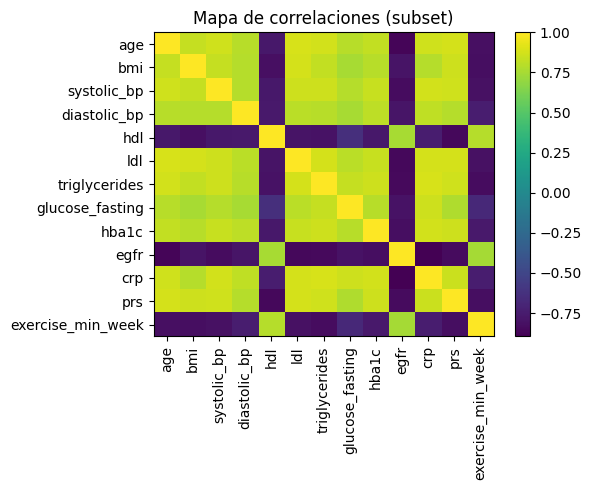

In [6]:

corr_features = ["age","bmi","systolic_bp","diastolic_bp","hdl","ldl","triglycerides",
                 "glucose_fasting","hba1c","egfr","crp","prs","exercise_min_week"]
corr = df[corr_features].corr().values

plt.figure(figsize=(6,5))
plt.imshow(corr, aspect='auto', interpolation='nearest')
plt.xticks(range(len(corr_features)), corr_features, rotation=90)
plt.yticks(range(len(corr_features)), corr_features)
plt.title("Mapa de correlaciones (subset)")
plt.colorbar()
plt.tight_layout()
plt.show()


In [7]:

# 3) Clasificación con KNN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df.drop(columns=["cluster"]).values
y = df["cluster"].map({"A":0, "B":1, "C":2}).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5, weights="distance")
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print("Accuracy (test):", round(acc, 3))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=["A","B","C"]))


Accuracy (test): 1.0
Matriz de confusión:
 [[9 0 0]
 [0 9 0]
 [0 0 7]]

Reporte de clasificación:
               precision    recall  f1-score   support

           A       1.00      1.00      1.00         9
           B       1.00      1.00      1.00         9
           C       1.00      1.00      1.00         7

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



In [8]:

# 4) Operacionalización: una línea estilo laboratorio (CSV sin encabezado)
feature_order = [c for c in df.drop(columns=["cluster"]).columns]

def model_predict_from_lab_line(line: str):
    parts = line.strip().split(",")
    if len(parts) != len(feature_order):
        raise ValueError(f"Se esperaban {len(feature_order)} valores, se recibieron {len(parts)}")
    vals = np.array([float(x) for x in parts], dtype=float).reshape(1, -1)
    vals_scaled = scaler.transform(vals)
    pred = knn.predict(vals_scaled)[0]
    proba = knn.predict_proba(vals_scaled)[0]
    label_map = {0:"A (bajo riesgo metabólico)", 1:"B (riesgo intermedio)", 2:"C (alto riesgo cardio-renal)"}
    return int(pred), label_map[int(pred)], proba

b_median = df[df["cluster"]=="B"].drop(columns=["cluster"]).median().tolist()
lab_line = ",".join([f"{x:.4f}" for x in b_median])
pred_idx, pred_label, pred_proba = model_predict_from_lab_line(lab_line)

print("Orden de columnas (CSV):")
print(feature_order)
print("\nLínea ejemplo (lab feed):")
print(lab_line)
print("\nPredicción:", pred_label, " | Probabilidades:", np.round(pred_proba, 3))


Orden de columnas (CSV):
['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'resting_hr', 'hdl', 'ldl', 'triglycerides', 'total_chol', 'glucose_fasting', 'hba1c', 'alt', 'ast', 'crp', 'creatinine', 'egfr', 'wbc', 'rbc', 'platelets', 'prs', 'exercise_min_week', 'pc1', 'pc2', 'sex_at_birth', 'smoking_index', 'bp_medication', 'statin_use']

Línea ejemplo (lab feed):
52.0021,29.6445,134.8223,85.1883,76.0227,44.7479,140.6750,181.4786,219.8932,104.7305,5.9803,34.9896,30.2920,2.8199,1.0807,89.2933,7.6182,5.0822,273.7935,0.5865,55.6180,0.4912,-0.2823,1.0000,1.0000,0.0000,0.0000

Predicción: B (riesgo intermedio)  | Probabilidades: [0. 1. 0.]


In [9]:

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("knn.pkl", "wb") as f:
    pickle.dump(knn, f)
print("Artefactos guardados: scaler.pkl, knn.pkl")


Artefactos guardados: scaler.pkl, knn.pkl


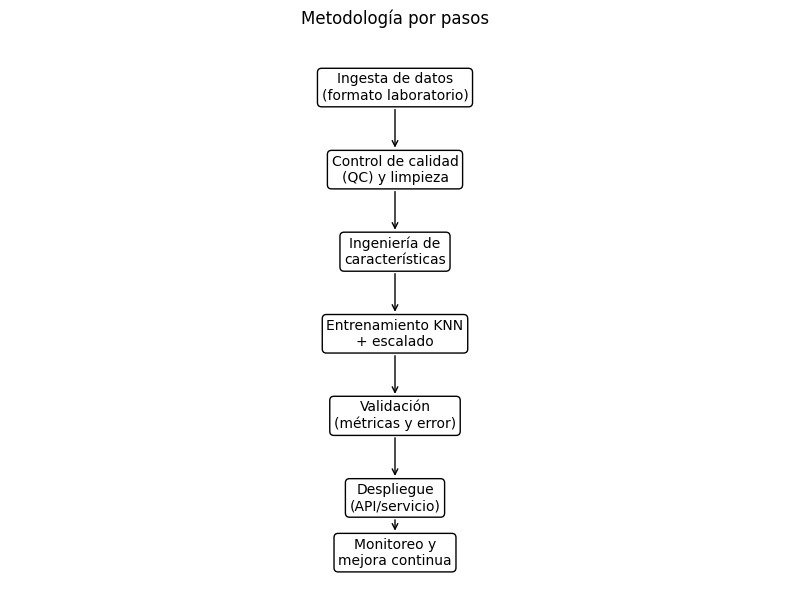

In [10]:

# 5) Diagrama simple de metodología (un gráfico)
plt.figure(figsize=(8, 6))
plt.axis('off')

boxes = [
    (0.5, 0.9, "Ingesta de datos\n(formato laboratorio)"),
    (0.5, 0.75, "Control de calidad\n(QC) y limpieza"),
    (0.5, 0.60, "Ingeniería de\ncaracterísticas"),
    (0.5, 0.45, "Entrenamiento KNN\n+ escalado"),
    (0.5, 0.30, "Validación\n(métricas y error)"),
    (0.5, 0.15, "Despliegue\n(API/servicio)"),
    (0.5, 0.05, "Monitoreo y\nmejora continua")
]

for (x, y, text) in boxes:
    plt.text(x, y, text, ha='center', va='center', bbox=dict(boxstyle="round", fc="white"), fontsize=10)

for i in range(len(boxes)-1):
    x0, y0, _ = boxes[i]
    x1, y1, _ = boxes[i+1]
    plt.annotate("", xy=(x1, y1+0.035), xytext=(x0, y0-0.035), arrowprops=dict(arrowstyle="->"))

plt.title("Metodología por pasos")
plt.tight_layout()
plt.show()
